## Full update example

One Belief state, one item, one observed response category.
We print the key scalars and then draw three figures:

1. Prior category probabilities (bar chart, observed category highlighted)
2. Projected score distribution with threshold lines and selected interval
3. Belief-state ellipses in 2-D latent space (prior → undamped → damped)

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\49160\Adaptive-Onboarding")
sys.path.append(str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\49160\Adaptive-Onboarding


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

from src.belief import BeliefState
from src.item_bank import Item
from src.grm import category_probabilities
from src.updates import (
    projected_mean_variance,
    one_step_posterior_coefficients,
    update_belief,
    damped_update_belief,
)
from src.plots import apply_notebook_style

apply_notebook_style()


In [15]:
belief = BeliefState(
    mu=np.array([1.5, 2.0]),
    Sigma=np.array([[2.0, 0.5], [0.5, 3.0]]),
)

item = Item(
    item_id="q_demo",
    a=np.array([1.0, -1.0]),
    thresholds=np.array([-2.0, 0.0, 1.5]),
    is_sensitive=True,
    sensitivity_level=0.5,
)

RESPONSE = 1

probs = category_probabilities(belief, item)
m, v, p_r = one_step_posterior_coefficients(belief, item, RESPONSE)

mu_eta_prior, var_eta_prior = projected_mean_variance(belief, item)
belief_undamped = update_belief(belief, item, RESPONSE)
belief_damped = damped_update_belief(belief, item, RESPONSE)
_, var_eta_undamp = projected_mean_variance(belief_undamped, item)
_, var_eta_damp = projected_mean_variance(belief_damped, item)

print("Prior category probabilities:")
for r, p in enumerate(probs):
    marker = "  <- observed" if r == RESPONSE else ""
    print(f"  r={r}: {p:.4f}{marker}")

print(f"\nm  (conditional mean shift coeff.) : {m:+.4f}")
print(f"v  (conditional variance factor)   : {v:.4f}")
print(f"p_r (predictive prob. of r={RESPONSE})   : {p_r:.4f}")

print("\nProjected variance  a^T Sigma a")
print(f"  prior    : {var_eta_prior:.4f}")
print(f"  undamped : {var_eta_undamp:.4f}  (Delta = {var_eta_undamp - var_eta_prior:+.4f})")
print(f"  damped   : {var_eta_damp:.4f}  (Delta = {var_eta_damp - var_eta_prior:+.4f})")


Prior category probabilities:
  r=0: 0.2512
  r=1: 0.3373  <- observed
  r=2: 0.2260
  r=3: 0.1855

m  (conditional mean shift coeff.) : -0.1870
v  (conditional variance factor)   : 0.2518
p_r (predictive prob. of r=1)   : 0.3373

Projected variance  a^T Sigma a
  prior    : 4.0000
  undamped : 1.0073  (Delta = -2.9927)
  damped   : 1.9979  (Delta = -2.0021)


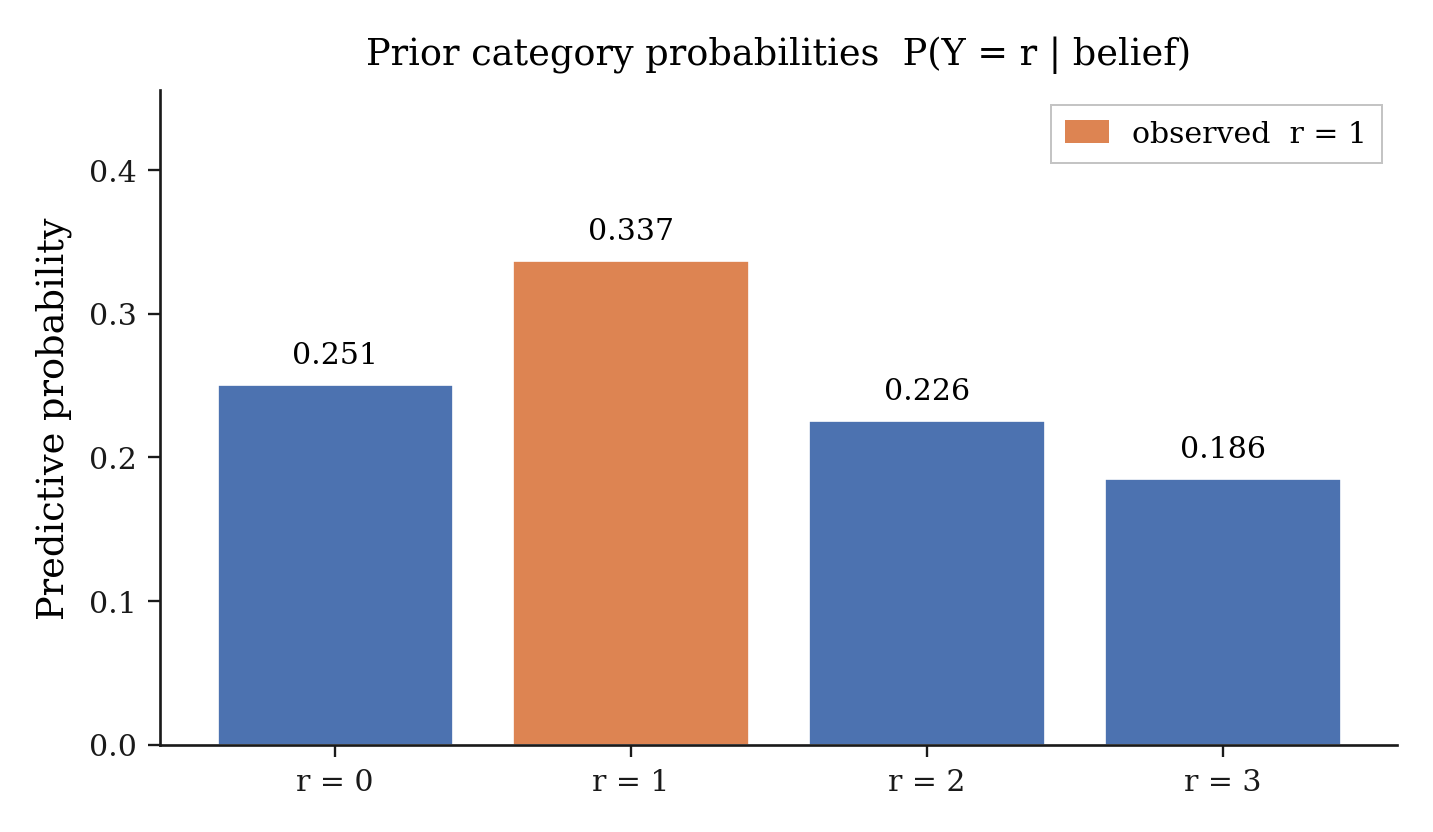

In [16]:
### Figure 1 – Prior category probabilities

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#4C72B0"] * len(probs)
colors[RESPONSE] = "#DD8452"          # highlight observed category

bars = ax.bar(range(len(probs)), probs, color=colors, edgecolor="white", linewidth=0.8)
ax.set_xticks(range(len(probs)))
ax.set_xticklabels([f"r = {r}" for r in range(len(probs))])
ax.set_ylabel("Predictive probability")
ax.set_title("Prior category probabilities  P(Y = r | belief)")
ax.set_ylim(0, min(1.05, max(probs) * 1.35))

for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{p:.3f}", ha="center", va="bottom", fontsize=9)

observed_patch = mpatches.Patch(color="#DD8452", label=f"observed  r = {RESPONSE}")
ax.legend(handles=[observed_patch], loc="upper right")
plt.tight_layout()
plt.show()

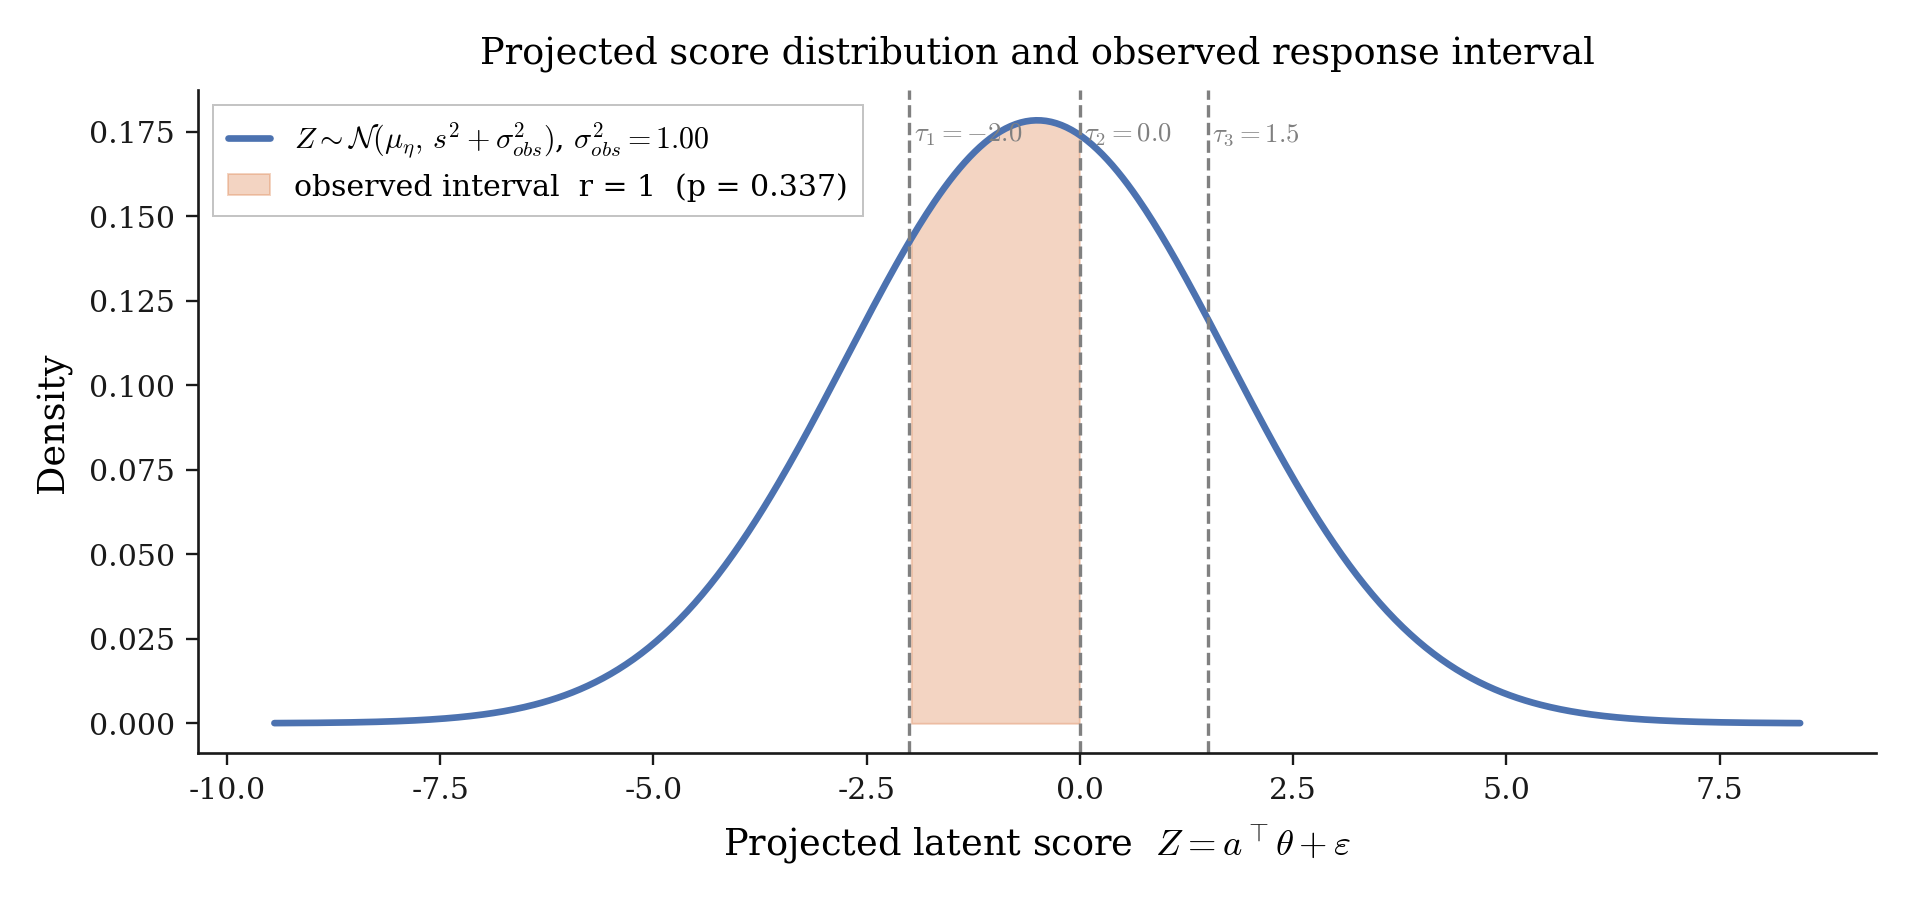

In [17]:
### Figure 2 – Projected score distribution with thresholds

from scipy import stats as sp_stats

# Marginal of Z = a^T theta + eps ~ N(mu_eta, var_eta + sigma_obs^2)
z_mean = mu_eta_prior
sigma_obs2 = item.observation_noise_variance
z_std = np.sqrt(var_eta_prior + sigma_obs2)

# Extended thresholds including -inf / +inf sentinels
thr_full = np.concatenate([[-np.inf], item.thresholds, [np.inf]])
lo, hi = thr_full[RESPONSE], thr_full[RESPONSE + 1]

z_plot = np.linspace(z_mean - 4 * z_std, z_mean + 4 * z_std, 600)
pdf = sp_stats.norm.pdf(z_plot, z_mean, z_std)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(
    z_plot,
    pdf,
    color="#4C72B0",
    linewidth=2,
    label=rf"$Z \sim \mathcal{{N}}(\mu_\eta,\,s^2+\sigma_{{obs}}^2)$, $\sigma_{{obs}}^2={sigma_obs2:.2f}$",
)

# Shade the selected interval
shade_lo = max(lo, z_plot[0]) if not np.isinf(lo) else z_plot[0]
shade_hi = min(hi, z_plot[-1]) if not np.isinf(hi) else z_plot[-1]
mask = (z_plot >= shade_lo) & (z_plot <= shade_hi)
ax.fill_between(
    z_plot[mask],
    pdf[mask],
    alpha=0.35,
    color="#DD8452",
    label=f"observed interval  r = {RESPONSE}  (p = {p_r:.3f})",
)

# Threshold lines
for i, tau in enumerate(item.thresholds):
    ax.axvline(tau, color="grey", linestyle="--", linewidth=1.0)
    ax.text(tau + 0.05, ax.get_ylim()[1] * 0.92, f"$\\tau_{{{i+1}}}={tau}$", fontsize=8, color="grey")

ax.set_xlabel("Projected latent score  $Z = a^\\top\\theta + \\varepsilon$")
ax.set_ylabel("Density")
ax.set_title("Projected score distribution and observed response interval")
ax.legend()
plt.tight_layout()
plt.show()

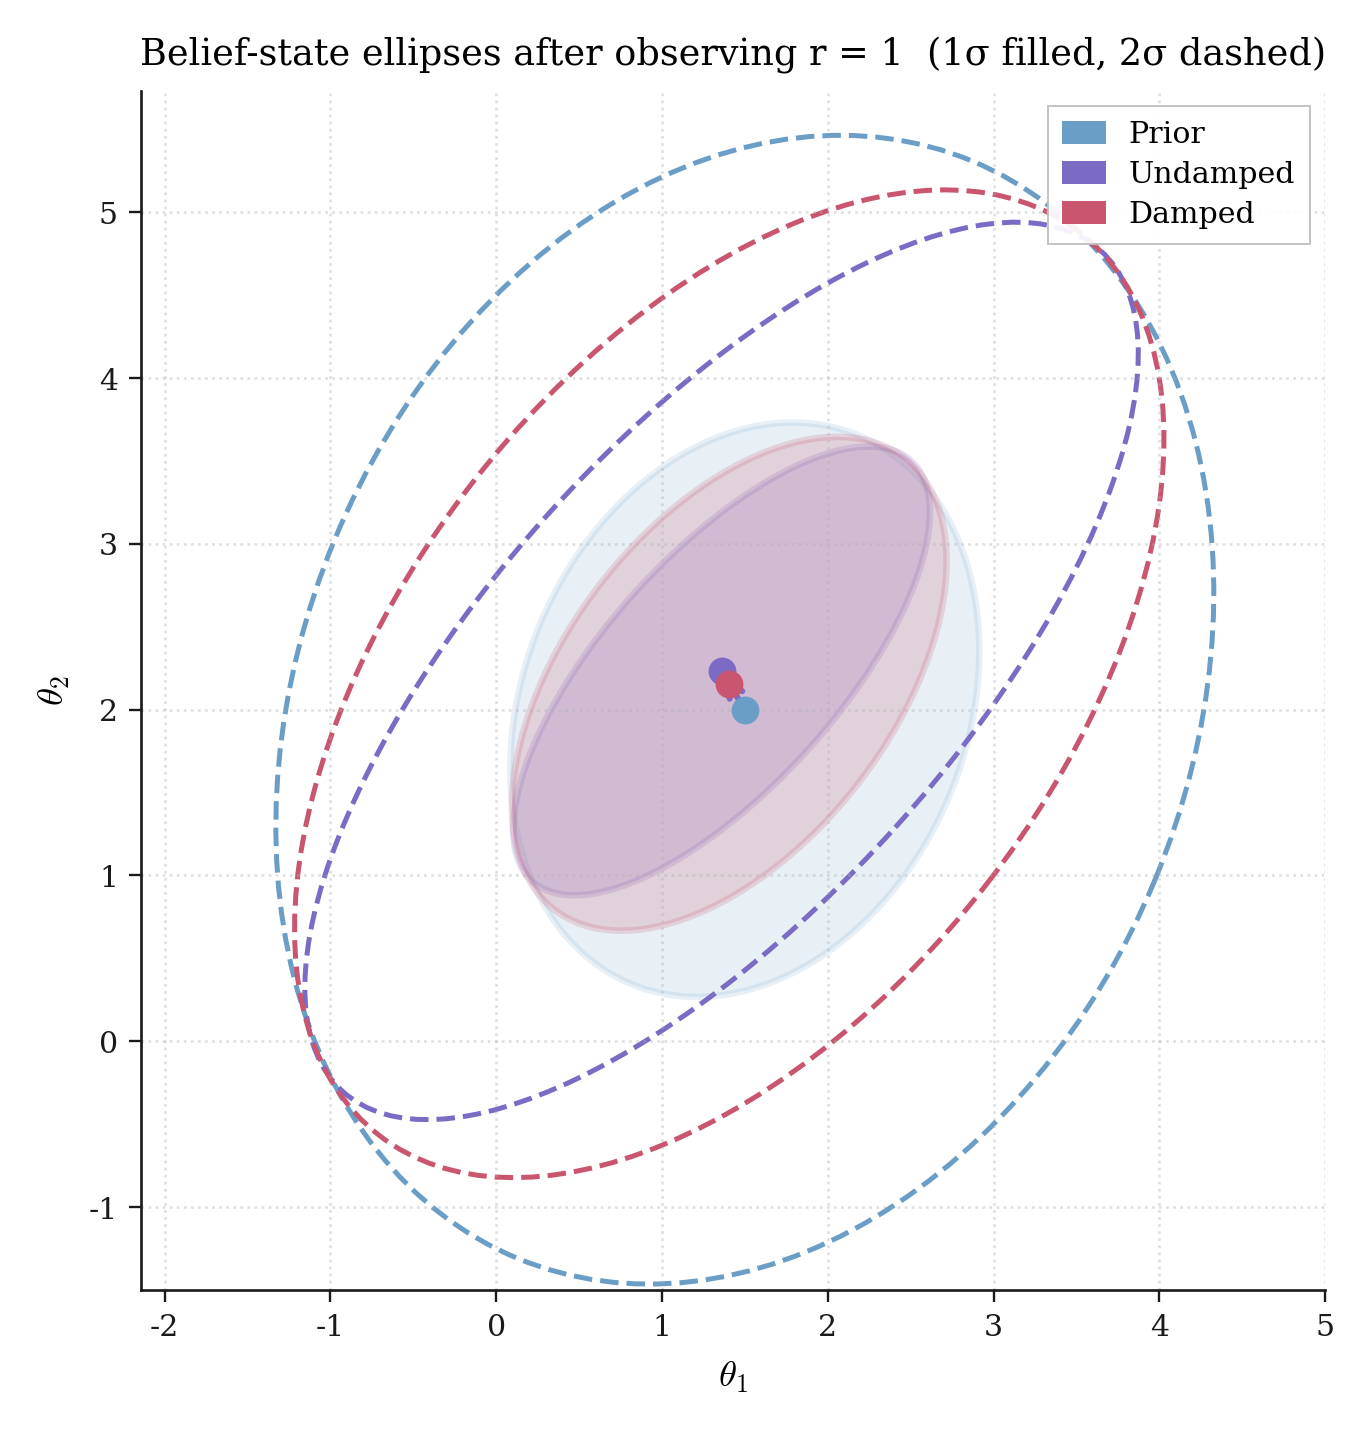

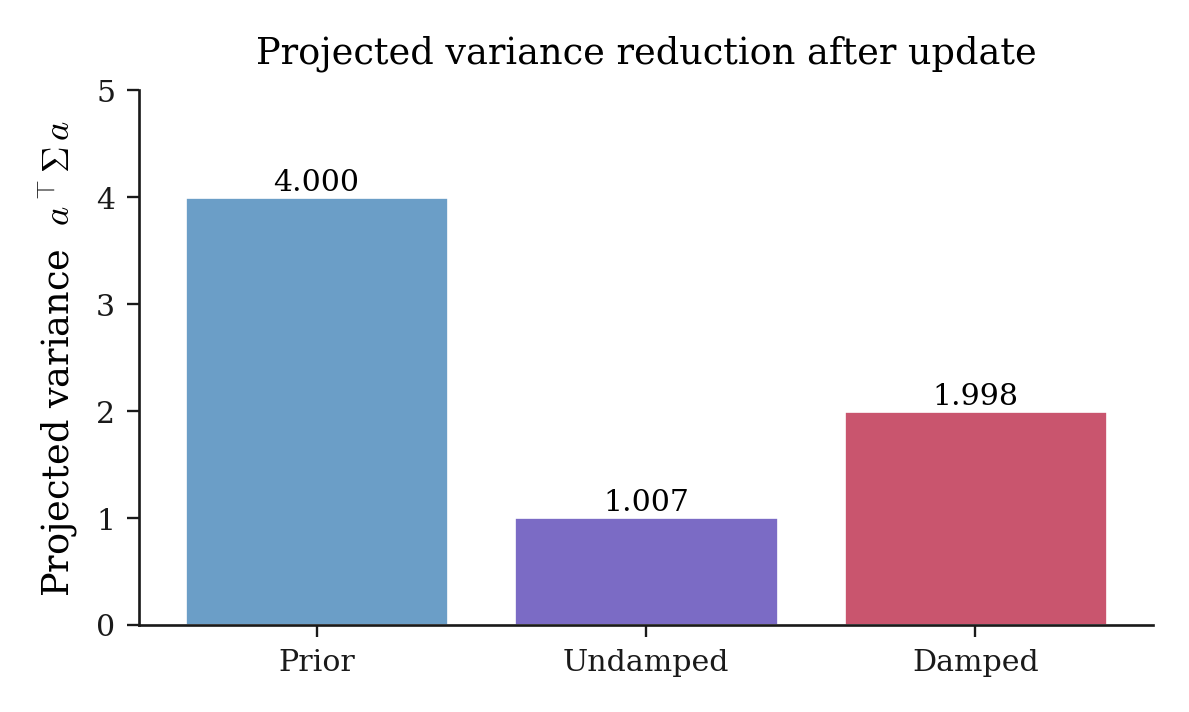

In [18]:
### Figure 3 – 2-D belief-state ellipses (prior → undamped → damped)

def cov_ellipse(ax, mu, Sigma, n_std=2.0, **kwargs):
    """Draw a covariance ellipse at n_std standard deviations."""
    vals, vecs = np.linalg.eigh(Sigma)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

fig, ax = plt.subplots(figsize=(7, 6))

from src.plots import BELIEF_PRIOR as PRIOR_C, BELIEF_UNDAMPED as UNDAMPED_C, BELIEF_DAMPED as DAMPED_C

styles = [
    (belief,          PRIOR_C,    "Prior",    0.15),
    (belief_undamped, UNDAMPED_C, "Undamped", 0.20),
    (belief_damped,   DAMPED_C,   "Damped",   0.20),
]

for bst, color, label, alpha in styles:
    cov_ellipse(ax, bst.mu, bst.Sigma, n_std=1, facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
    cov_ellipse(ax, bst.mu, bst.Sigma, n_std=2, facecolor="none",               edgecolor=color, linewidth=1.5, linestyle="--")
    ax.scatter(*bst.mu, color=color, zorder=5, s=60)

# Update direction arrow (prior → undamped mean)
delta_mu = belief_undamped.mu - belief.mu
ax.annotate("", xy=belief_undamped.mu, xytext=belief.mu,
            arrowprops=dict(arrowstyle="->", color=UNDAMPED_C, lw=1.8))

# Legend
legend_handles = [
    mpatches.Patch(facecolor=c, edgecolor=c, label=lbl)
    for _, c, lbl, _ in styles
]
ax.legend(handles=legend_handles, loc="upper right")

# Axis labels and limits
all_mus = np.stack([b.mu for b, *_ in styles])
pad = 3.5
ax.set_xlim(all_mus[:, 0].min() - pad, all_mus[:, 0].max() + pad)
ax.set_ylim(all_mus[:, 1].min() - pad, all_mus[:, 1].max() + pad)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title(f"Belief-state ellipses after observing r = {RESPONSE}  (1σ filled, 2σ dashed)")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Projected variance summary ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
labels = ["Prior", "Undamped", "Damped"]
values = [var_eta_prior, var_eta_undamp, var_eta_damp]
bar_colors = [PRIOR_C, UNDAMPED_C, DAMPED_C]

bars = ax.bar(labels, values, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel(r"Projected variance  $a^\top \Sigma\, a$")
ax.set_title("Projected variance reduction after update")
ax.set_ylim(0, max(values) * 1.25)
plt.tight_layout()
plt.show()